<a href="https://colab.research.google.com/github/AnwHus007/IPL-2025-PBI/blob/main/IPL_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import zipfile
import json
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

!wget -q https://cricsheet.org/downloads/ipl_json.zip -O /content/ipl_json.zip
zip_file_path = '/content/ipl_json.zip'
extraction_directory = '/content/cricsheet_data'

os.makedirs(extraction_directory, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_directory)

In [3]:
def get_ipl_2025_files(folder_path):
    print("Scanning the data lake for IPL 2025 matches")

    all_files = glob.glob(os.path.join(folder_path, "*.json"))
    ipl_2025_files = []

    for file_path in all_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                data = json.load(file)
                info = data.get('info', {})

                # 1. Check the Tournament Name
                event_name = info.get('event', {}).get('name', '')

                # 2. Check the Year
                season = str(info.get('season', ''))
                match_dates = info.get('dates', [])
                is_2025 = (season == '2025') or any('2025' in date for date in match_dates)
                if event_name == "Indian Premier League" and is_2025:
                    ipl_2025_files.append(file_path)

        except Exception:
            continue

    print(f"Found {len(ipl_2025_files)} IPL 2025 matches.")

    return ipl_2025_files

In [4]:
def process_ipl_data(file_paths):
    print("Started ETL Process")

    match_list = []
    deliveries_list = []

    for file_path in file_paths:
        with open(file_path, 'r', encoding='utf-8') as file:
            data = json.load(file)

            # The filename itself is the official match ID
            match_id = os.path.basename(file_path).replace('.json', '')

            # 'info' holds all the high-level match details like date, venue, and toss
            info = data.get('info', {})
            outcome = info.get('outcome', {})
            actual_winner = outcome.get('winner', outcome.get('eliminator', 'No Result'))
            match_row = {
                'Match_ID': match_id,
                'Date': info.get('dates', [None])[0],
                'City': info.get('city', 'Unknown'),
                'Venue': info.get('venue', 'Unknown'),
                'Team_1': info.get('teams', [None, None])[0],
                'Team_2': info.get('teams', [None, None])[1],
                'Toss_Winner': info.get('toss', {}).get('winner'),
                'Toss_Decision': info.get('toss', {}).get('decision'),
                'Match_Winner': actual_winner,
                'Player_of_Match': info.get('player_of_match', [None])[0]
            }
            match_list.append(match_row)

            # Ball-by-ball details
            for innings in data.get('innings', []):
                batting_team = innings.get('team')

                for over_data in innings.get('overs', []):
                    over_num = over_data.get('over')

                    for ball_idx, delivery in enumerate(over_data.get('deliveries', [])):

                        # 1. Handling Extras:
                        # We need to separate wides and no-balls from byes and leg-byes.
                        # Wides/no-balls mean the bowler has to bowl the ball again (not a legal delivery),
                        # while byes/leg-byes do not count against the bowler's runs conceded.
                        extras_dict = delivery.get('extras', {})
                        wides = 1 if 'wides' in extras_dict else 0
                        noballs = 1 if 'noballs' in extras_dict else 0
                        byes = extras_dict.get('byes', 0)
                        legbyes = extras_dict.get('legbyes', 0)

                        # 2. Handling Wickets:
                        # If the 'wickets' key exists, someone got out.
                        # We need to know 'how' they got out (Dismissal_Kind) to see if the bowler gets credit,
                        # and specifically 'who' got out (Player_Out) because the non-striker could be run out
                        is_wicket = 1 if 'wickets' in delivery else 0
                        dismissal_kind = delivery['wickets'][0].get('kind') if is_wicket else None
                        player_out = delivery['wickets'][0].get('player_out') if is_wicket else None

                        # 3. Handling Impact Players:
                        # IPL features mid-match substitutions. If a 'replacements' key pops up during a delivery,
                        # we flag it so we can analyze the impact player rule later in our dashboard.
                        has_substitution = 1 if 'replacements' in delivery else 0

                        # Construct the row for this single delivery
                        delivery_row = {
                            'Match_ID': match_id,
                            'Batting_Team': batting_team,
                            'Over_Number': over_num,
                            'Ball_Number': ball_idx + 1,
                            'Batter': delivery.get('batter'),
                            'Bowler': delivery.get('bowler'),
                            'Runs_Batter': delivery.get('runs', {}).get('batter', 0),
                            'Runs_Extras': delivery.get('runs', {}).get('extras', 0),
                            'Runs_Total': delivery.get('runs', {}).get('total', 0),
                            'Is_Wide': wides,
                            'Is_NoBall': noballs,
                            'Byes': byes,
                            'LegByes': legbyes,
                            'Is_Wicket': is_wicket,
                            'Dismissal_Kind': dismissal_kind,
                            'Player_Out': player_out,
                            'Substitution_Event': has_substitution
                        }

                        deliveries_list.append(delivery_row)

    # Convert our populated lists into Pandas DataFrames
    df_match = pd.DataFrame(match_list)
    df_deliveries = pd.DataFrame(deliveries_list)

    df_match['Date'] = pd.to_datetime(df_match['Date'])

    print("ETL completed")
    return df_match, df_deliveries

In [5]:
file_paths = get_ipl_2025_files('/content/cricsheet_data')

if file_paths:
    df_match, df_deliveries = process_ipl_data(file_paths)

    df_match.to_csv('Match_IPL2025.csv', index=False)
    df_deliveries.to_csv('Deliveries_IPL2025.csv', index=False)
    print("CSV files saved")
else:
    print("No IPL 2025 JSON files found.")

Scanning the data lake for IPL 2025 matches
Found 74 IPL 2025 matches.
Started ETL Process
ETL completed
CSV files saved


In [6]:
df_match.head()

,Match_ID,Date,City,Venue,Team_1,Team_2,Toss_Winner,Toss_Decision,Match_Winner,Player_of_Match
0,1473487,2025-05-01,Jaipur,"Sawai Mansingh Stadium, Jaipur",Mumbai Indians,Rajasthan Royals,Rajasthan Royals,field,Mumbai Indians,RD Rickelton
1,1473457,2025-04-06,Hyderabad,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Sunrisers Hyderabad,Gujarat Titans,Gujarat Titans,field,Gujarat Titans,Mohammed Siraj
2,1473480,2025-04-25,Chennai,"MA Chidambaram Stadium, Chepauk, Chennai",Chennai Super Kings,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,HV Patel
3,1473503,2025-05-23,Lucknow,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Sunrisers Hyderabad,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,Sunrisers Hyderabad,Ishan Kishan
4,1473492,2025-05-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Delhi Capitals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,No Result,None


In [7]:
df_deliveries.head()

,Match_ID,Batting_Team,Over_Number,Ball_Number,Batter,Bowler,Runs_Batter,Runs_Extras,Runs_Total,Is_Wide,Is_NoBall,Byes,LegByes,Is_Wicket,Dismissal_Kind,Player_Out,Substitution_Event
0,1473487,Mumbai Indians,0,1,RD Rickelton,JC Archer,0,0,0,0,0,0,0,0,None,None,0
1,1473487,Mumbai Indians,0,2,RD Rickelton,JC Archer,1,0,1,0,0,0,0,0,None,None,0
2,1473487,Mumbai Indians,0,3,RG Sharma,JC Archer,0,0,0,0,0,0,0,0,None,None,0
3,1473487,Mumbai Indians,0,4,RG Sharma,JC Archer,0,0,0,0,0,0,0,0,None,None,0
4,1473487,Mumbai Indians,0,5,RG Sharma,JC Archer,1,0,1,0,0,0,0,0,None,None,0


In [38]:
len(df_deliveries)

17285

In [8]:
def build_relational_schema(match_data, delivery_data):
    print("Transforming raw data into a clean relational model...")

    # 1. Create the Teams Table
    # Master list of all unique teams. Keep only the unique names.
    all_teams = pd.concat([
        match_data['Team_1'],
        match_data['Team_2'],
        match_data['Toss_Winner'],
        match_data['Match_Winner']
    ]).dropna().unique()

    teams_table = pd.DataFrame({'Team_Name': all_teams}).reset_index()
    teams_table['Team_ID'] = teams_table['index'] + 1
    teams_table.drop(columns=['index'], inplace=True)

    # 2. Create the Venues Table
    # Grab unique stadium and city combinations
    venues_table = match_data[['Venue', 'City']].dropna(subset=['Venue']).drop_duplicates().reset_index(drop=True).reset_index()
    venues_table['Venue_ID'] = venues_table['index'] + 1
    venues_table.drop(columns=['index'], inplace=True)

    # 3. Create the Players Table
    # This is our lookup table for batters, bowlers, players of the match, and anyone who got out (to catch non-strikers).
    all_players = pd.concat([
        delivery_data['Batter'],
        delivery_data['Bowler'],
        delivery_data['Player_Out'],
        match_data['Player_of_Match']
    ]).dropna().unique()

    players_table = pd.DataFrame({'Player_Name': all_players}).reset_index()
    players_table['Player_ID'] = players_table['index'] + 1
    players_table.drop(columns=['index'], inplace=True)

    # 4. Build Mapping Dictionaries
    team_dict = dict(zip(teams_table['Team_Name'], teams_table['Team_ID']))
    venue_dict = dict(zip(venues_table['Venue'], venues_table['Venue_ID']))
    player_dict = dict(zip(players_table['Player_Name'], players_table['Player_ID']))

    # 5. Optimize the Matches Table
    # Swap out text names to integer IDs.
    matches_relational = match_data.copy()
    matches_relational['Team_1_ID'] = matches_relational['Team_1'].map(team_dict)
    matches_relational['Team_2_ID'] = matches_relational['Team_2'].map(team_dict)
    matches_relational['Toss_Winner_ID'] = matches_relational['Toss_Winner'].map(team_dict)
    matches_relational['Match_Winner_ID'] = matches_relational['Match_Winner'].map(team_dict)
    matches_relational['Venue_ID'] = matches_relational['Venue'].map(venue_dict)
    matches_relational['Player_of_Match_ID'] = matches_relational['Player_of_Match'].map(player_dict)

    # Drop the old text columns to shrink the file size
    columns_to_drop_match = ['Team_1', 'Team_2', 'Toss_Winner', 'Match_Winner', 'Venue', 'City', 'Player_of_Match']
    matches_relational.drop(columns=columns_to_drop_match, inplace=True, errors='ignore')

    # 6. Optimize the Deliveries Table
    # Do the exact same mapping for our massive ball-by-ball dataset.
    deliveries_relational = delivery_data.copy()
    deliveries_relational['Batting_Team_ID'] = deliveries_relational['Batting_Team'].map(team_dict)
    deliveries_relational['Batter_ID'] = deliveries_relational['Batter'].map(player_dict)
    deliveries_relational['Bowler_ID'] = deliveries_relational['Bowler'].map(player_dict)
    deliveries_relational['Player_Out_ID'] = deliveries_relational['Player_Out'].map(player_dict)

    # Drop the original text columns here too
    deliveries_relational.drop(columns=['Batting_Team', 'Batter', 'Bowler', 'Player_Out'], inplace=True, errors='ignore')

    print("Data normalized successfully.")
    return teams_table, venues_table, players_table, matches_relational, deliveries_relational

# Execute the Pipeline
# Make sure to pass in the DataFrames you generated from the previous step
teams_table, venues_table, players_table, matches_relational, deliveries_relational = build_relational_schema(df_match, df_deliveries)

print("\nPlayers Table Preview:")
display(players_table.head(3))

# Export the final tables
teams_table.to_csv('Teams.csv', index=False)
venues_table.to_csv('Venues.csv', index=False)
players_table.to_csv('Players.csv', index=False)
matches_relational.to_csv('Matches.csv', index=False)
deliveries_relational.to_csv('Deliveries.csv', index=False)

Transforming raw data into a clean relational model...
Data normalized successfully.

Players Table Preview:


,Player_Name,Player_ID
0,RD Rickelton,1
1,RG Sharma,2
2,SA Yadav,3


/tmp/ipykernel_155/3672994643.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_venue_totals.values, y=avg_venue_totals.index, ax=axes[0, 1], palette='magma')
/tmp/ipykernel_155/3672994643.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_runs['Runs_Total'], y=team_runs['Batting_Team'], ax=axes[0, 0], palette='viridis')


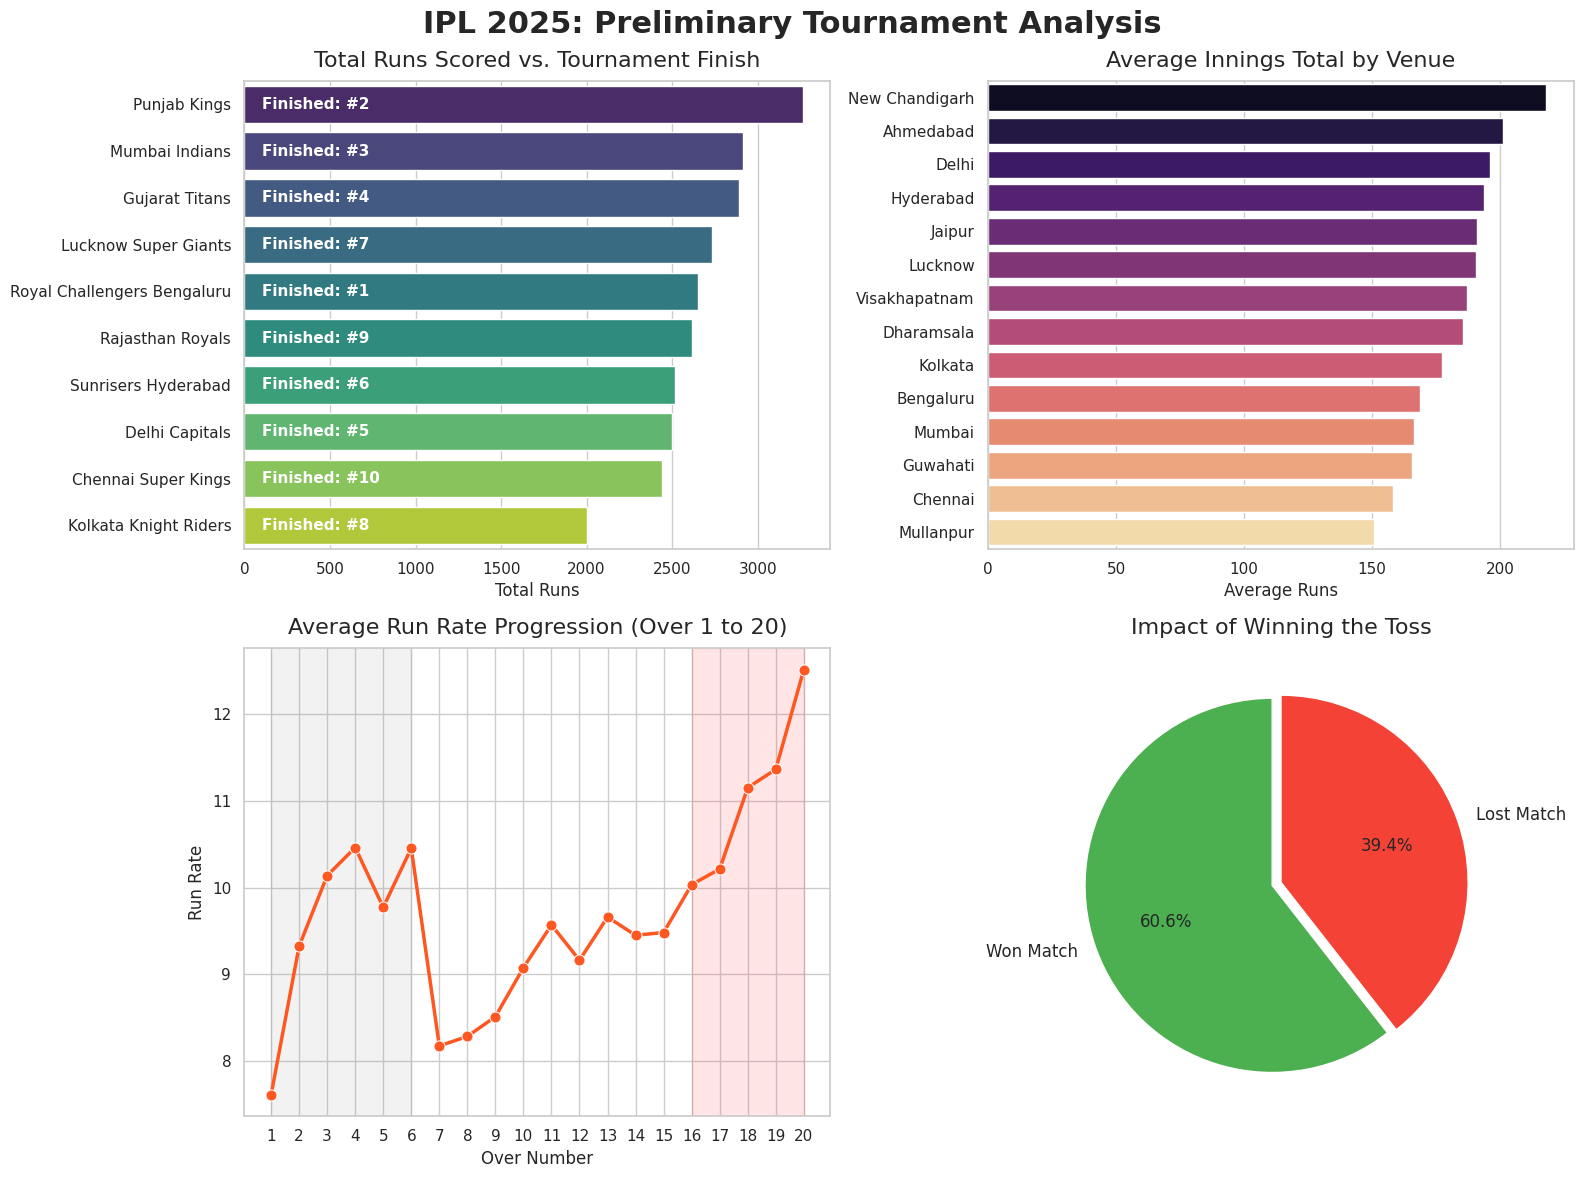

In [37]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('IPL 2025: Preliminary Tournament Analysis', fontsize=22, fontweight='bold', y=0.98)


# Average innings total by venue

innings_totals = df_deliveries.groupby(['Match_ID', 'Batting_Team'])['Runs_Total'].sum().reset_index()
innings_venues = innings_totals.merge(df_match[['Match_ID', 'Venue']], on='Match_ID', how='left')
innings_venues['Venue_Place'] = innings_venues['Venue'].apply(lambda x: str(x).split(',')[-1].strip())
avg_venue_totals = innings_venues.groupby('Venue_Place')['Runs_Total'].mean().sort_values(ascending=False)

sns.barplot(x=avg_venue_totals.values, y=avg_venue_totals.index, ax=axes[0, 1], palette='magma')

axes[0, 1].set_title('Average Innings Total by Venue', fontsize=16, pad=10)
axes[0, 1].set_xlabel('Average Runs', fontsize=12)
axes[0, 1].set_ylabel('')


# Toss Decision Impact

toss_impact = df_match.copy()
# Filter out No Results
toss_impact = toss_impact[toss_impact['Match_Winner'] != 'No Result']
toss_impact['Toss_Win_Match_Win'] = toss_impact['Toss_Winner'] == toss_impact['Match_Winner']
impact_counts = toss_impact['Toss_Win_Match_Win'].value_counts()
labels = ['Won Match', 'Lost Match'] if impact_counts.index[0] == True else ['Lost Match', 'Won Match']
axes[1, 1].pie(impact_counts, labels=labels, autopct='%1.1f%%', startangle=90,
               colors=['#4CAF50', '#F44336'], textprops={'fontsize': 12}, explode=(0.05, 0))
axes[1, 1].set_title('Impact of Winning the Toss', fontsize=16, pad=10)

# Tournament Run Rate by Over

# Calculate the average run rate for every over
runs_per_over = df_deliveries.groupby('Over_Number')['Runs_Total'].sum()
# Count only legal deliveries to get true overs bowled
legal_balls_per_over = df_deliveries[(df_deliveries['Is_Wide'] == 0) & (df_deliveries['Is_NoBall'] == 0)].groupby('Over_Number').size()
run_rate = (runs_per_over / legal_balls_per_over) * 6
run_rate.index = run_rate.index + 1
sns.lineplot(x=run_rate.index, y=run_rate.values, ax=axes[1, 0], marker='o', color='#FF5722', linewidth=2.5, markersize=8)
axes[1, 0].set_title('Average Run Rate Progression (Over 1 to 20)', fontsize=16, pad=10)
axes[1, 0].set_xlabel('Over Number', fontsize=12)
axes[1, 0].set_ylabel('Run Rate', fontsize=12)
axes[1, 0].set_xticks(range(1, 21))
# Powerplay
axes[1, 0].axvspan(1, 6, color='gray', alpha=0.1)
# Death Overs
axes[1, 0].axvspan(16, 20, color='red', alpha=0.1)

# Total Runs Scored by Team

# Official IPL 2025 Ranking
official_rankings = {
    'Royal Challengers Bengaluru': 1,
    'Punjab Kings': 2,
    'Mumbai Indians': 3,
    'Gujarat Titans': 4,
    'Delhi Capitals': 5,
    'Sunrisers Hyderabad': 6,
    'Lucknow Super Giants': 7,
    'Kolkata Knight Riders': 8,
    'Rajasthan Royals': 9,
    'Chennai Super Kings': 10
}

team_runs = df_deliveries.groupby('Batting_Team')['Runs_Total'].sum().reset_index()
team_runs = team_runs.sort_values('Runs_Total', ascending=False).reset_index(drop=True)
team_runs['Official_Rank'] = team_runs['Batting_Team'].map(official_rankings)

sns.barplot(x=team_runs['Runs_Total'], y=team_runs['Batting_Team'], ax=axes[0, 0], palette='viridis')

axes[0, 0].set_title('Total Runs Scored vs. Tournament Finish', fontsize=16, pad=10)
axes[0, 0].set_xlabel('Total Runs', fontsize=12)
axes[0, 0].set_ylabel('')


# Loop through and stamp the tournament rank inside the bars
for i, p in enumerate(axes[0, 0].patches):
    rank = int(team_runs.loc[i, 'Official_Rank'])
    axes[0, 0].text(
        x=100,
        y=p.get_y() + p.get_height() / 2,
        s=f"Finished: #{rank}",
        color='white',
        ha='left',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

In [9]:
# BATTING LEADERBOARD (ORANGE CAP)

# Only wide is not counted as legal delivery for batsman
df_deliveries['Is_Legal_Bat_Ball'] = (df_deliveries['Is_Wide'] == 0).astype(int)
df_deliveries['Is_Four'] = (df_deliveries['Runs_Batter'] == 4).astype(int)
df_deliveries['Is_Six'] = (df_deliveries['Runs_Batter'] == 6).astype(int)

# Group by Batter and Match to get Innings-level stats
match_batting = df_deliveries.groupby(['Batter', 'Match_ID']).agg(
    Runs=('Runs_Batter', 'sum'),
    BF=('Is_Legal_Bat_Ball', 'sum'),
    Fours=('Is_Four', 'sum'),
    Sixes=('Is_Six', 'sum')
).reset_index()

# Determine if the batter was dismissed in each match
dismissals = df_deliveries[df_deliveries['Is_Wicket'] == 1][['Match_ID', 'Player_Out']].rename(columns={'Player_Out': 'Batter'})
dismissals['Is_Out'] = 1
match_batting = match_batting.merge(dismissals, on=['Match_ID', 'Batter'], how='left').fillna({'Is_Out': 0})

# Calculate milestones and Not Outs
match_batting['Is_Not_Out'] = 1 - match_batting['Is_Out']
match_batting['100s'] = (match_batting['Runs'] >= 100).astype(int)
match_batting['50s'] = ((match_batting['Runs'] >= 50) & (match_batting['Runs'] < 100)).astype(int)

# Aggregate overall tournament stats per batter
batting_overall = match_batting.groupby('Batter').agg(
    Mat=('Match_ID', 'nunique'),
    Inns=('Match_ID', 'count'),
    Runs=('Runs', 'sum'),
    BF=('BF', 'sum'),
    NO=('Is_Not_Out', 'sum'),
    Fours=('Fours', 'sum'),
    Sixes=('Sixes', 'sum'),
    Hundreds=('100s', 'sum'),
    Fifties=('50s', 'sum')
).reset_index()

# Calculate Highest Score (HS) and append '*' if Not Out
hs_df = match_batting.sort_values(by=['Batter', 'Runs', 'Is_Not_Out'], ascending=[True, False, False]).drop_duplicates(subset=['Batter'], keep='first')
hs_df['HS'] = hs_df.apply(lambda x: f"{int(x['Runs'])}*" if x['Is_Not_Out'] == 1 else f"{int(x['Runs'])}", axis=1)
batting_overall = batting_overall.merge(hs_df[['Batter', 'HS']], on='Batter', how='left')

# Calculate Average and Strike Rate
batting_overall['Outs'] = batting_overall['Inns'] - batting_overall['NO']
batting_overall['Avg'] = np.where(batting_overall['Outs'] > 0, batting_overall['Runs'] / batting_overall['Outs'], batting_overall['Runs'])
batting_overall['SR'] = (batting_overall['Runs'] / batting_overall['BF']) * 100

# Format and sort to match screenshot
batting_overall['Avg'] = batting_overall['Avg'].round(2)
batting_overall['SR'] = batting_overall['SR'].round(2)
batting_overall.rename(columns={'Batter': 'Player', 'Fours': '4s', 'Sixes': '6s', 'Hundreds': '100', 'Fifties': '50'}, inplace=True)

batting_top5 = batting_overall[['Player', 'Runs', 'Mat', 'Inns', 'NO', 'HS', 'Avg', 'BF', 'SR', '100', '50', '4s', '6s']]
batting_top5 = batting_top5.sort_values(by='Runs', ascending=False).head(5).reset_index(drop=True)
batting_top5.index += 1
batting_top5.index.name = 'POS'


In [10]:
# BOWLING LEADERBOARD (PURPLE CAP)

# Create fast flags for bowling calculations
valid_dismissals = ['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
df_deliveries['Bowler_Wicket'] = ((df_deliveries['Is_Wicket'] == 1) & (df_deliveries['Dismissal_Kind'].isin(valid_dismissals))).astype(int)
df_deliveries['Bowler_Runs'] = df_deliveries['Runs_Total'] - df_deliveries['Byes'] - df_deliveries['LegByes']
df_deliveries['Legal_Ball'] = ((df_deliveries['Is_Wide'] == 0) & (df_deliveries['Is_NoBall'] == 0)).astype(int)

# Group by Bowler and Match
match_bowl = df_deliveries.groupby(['Bowler', 'Match_ID']).agg(
    Wkts=('Bowler_Wicket', 'sum'),
    Runs=('Bowler_Runs', 'sum'),
    Legal_Balls=('Legal_Ball', 'sum')
).reset_index()

# Calculate Best Bowling Figure (BBI) per match
match_bowl = match_bowl.sort_values(by=['Bowler', 'Wkts', 'Runs'], ascending=[True, False, True])
bbi_df = match_bowl.drop_duplicates(subset=['Bowler'], keep='first').copy()
bbi_df['BBI'] = bbi_df['Wkts'].astype(str) + "/" + bbi_df['Runs'].astype(str)

# Calculate 4-wicket and 5-wicket hauls
match_bowl['4w'] = ((match_bowl['Wkts'] == 4)).astype(int)
match_bowl['5w'] = (match_bowl['Wkts'] >= 5).astype(int)

# Aggregate overall tournament stats per bowler
bowling_overall = match_bowl.groupby('Bowler').agg(
    Mat=('Match_ID', 'nunique'),
    Inns=('Match_ID', 'count'),
    Wkts=('Wkts', 'sum'),
    Runs=('Runs', 'sum'),
    Legal_Balls=('Legal_Balls', 'sum'),
    Fours_W=('4w', 'sum'),
    Fives_W=('5w', 'sum')
).reset_index()

# Merge BBI and calculate Overs, Economy, Average, Strike Rate
bowling_overall = bowling_overall.merge(bbi_df[['Bowler', 'BBI']], on='Bowler', how='left')
bowling_overall['Ov'] = (bowling_overall['Legal_Balls'] // 6) + (bowling_overall['Legal_Balls'] % 6) / 10
bowling_overall['Avg'] = np.where(bowling_overall['Wkts'] > 0, bowling_overall['Runs'] / bowling_overall['Wkts'], 0)
bowling_overall['Econ'] = np.where(bowling_overall['Legal_Balls'] > 0, (bowling_overall['Runs'] / bowling_overall['Legal_Balls']) * 6, 0)
bowling_overall['SR'] = np.where(bowling_overall['Wkts'] > 0, bowling_overall['Legal_Balls'] / bowling_overall['Wkts'], 0)

# Format and sort to match screenshot
bowling_overall['Avg'] = bowling_overall['Avg'].round(2)
bowling_overall['Econ'] = bowling_overall['Econ'].round(2)
bowling_overall['SR'] = bowling_overall['SR'].round(2)
bowling_overall.rename(columns={'Bowler': 'Player', 'Fours_W': '4w', 'Fives_W': '5w'}, inplace=True)

bowling_top5 = bowling_overall[['Player', 'Wkts', 'Mat', 'Inns', 'Ov', 'Runs', 'BBI', 'Avg', 'Econ', 'SR', '4w', '5w']]
# Sort by Wickets, then Economy Rate (tie-breaker)
bowling_top5 = bowling_top5.sort_values(by=['Wkts', 'Econ'], ascending=[False, True]).head(5).reset_index(drop=True)
bowling_top5.index += 1
bowling_top5.index.name = 'POS'



In [13]:
# Display the DataFrames
print("\nTOP 5 BATTING")
display(batting_top5)

print("\nTOP 5 BOWLING")
display(bowling_top5)


TOP 5 BATTING


,Player,Runs,Mat,Inns,NO,HS,Avg,BF,SR,100,50,4s,6s
POS,,,,,,,,,,,,,
1,B Sai Sudharsan,759,15,15,1.0,108*,54.21,486,156.17,1,6,88,21
2,SA Yadav,717,16,16,5.0,73*,65.18,427,167.92,0,5,69,38
3,V Kohli,657,15,15,3.0,73*,54.75,454,144.71,0,8,66,19
4,Shubman Gill,650,15,15,2.0,93*,50.00,417,155.88,0,6,62,24
5,MR Marsh,627,13,13,0.0,117,48.23,383,163.71,1,6,56,37



TOP 5 BOWLING


,Player,Wkts,Mat,Inns,Ov,Runs,BBI,Avg,Econ,SR,4w,5w
POS,,,,,,,,,,,,
1,M Prasidh Krishna,25,15,15,59.0,488,4/41,19.52,8.27,14.16,1,0
2,Noor Ahmad,24,14,14,50.0,408,4/18,17.00,8.16,12.50,2,0
3,JR Hazlewood,22,12,12,44.0,386,4/33,17.55,8.77,12.00,1,0
4,TA Boult,22,16,16,57.4,517,4/26,23.50,8.97,15.73,1,0
5,Arshdeep Singh,21,16,16,58.2,518,3/16,24.67,8.88,16.67,0,0
